LINK VIDEO PRESENTASI : https://drive.google.com/file/d/1tFmAAcXjMLn0tJssfa7hpOcGYz83R8w6/view?usp=sharing

LINK STREAMLIT GITHUB : https://model-deployment-uts-7esrfkm3gjwxldbnwo3uxy.streamlit.app/

# Soal 1: Exploratory Data Analysis & Modeling
Dataset: A (2802451781) — Fitur dan Target dalam file terpisah  
Task: Binary Classification (placement_status) + Regression (salary_lpa)  
Evaluasi: Classification → Accuracy, F1-Score, ROC-AUC | Regression → MAE, RMSE, R²

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
import joblib
import os

os.makedirs('../models', exist_ok=True)
sns.set_theme(style='whitegrid')
print('Libraries berhasil')

Libraries berhasil


## 2. Data Loading
Dataset A terdiri dari dua file terpisah: `A.csv` (fitur) dan `A_targets.csv` (target).  
Kedua file digabungkan menggunakan `Student_ID` sebagai **join key**.

In [7]:
features = pd.read_csv('C:\\Storage\\Documents\\Kuliah\\SEM 4\\MD\\UTS\\2802451781\\data\\A.csv')
targets  = pd.read_csv('C:\\Storage\\Documents\\Kuliah\\SEM 4\\MD\\UTS\\2802451781\\data\\A_targets.csv')

df = features.merge(targets, on='Student_ID')

print(f'Features shape : {features.shape}')
print(f'Targets shape  : {targets.shape}')
print(f'Merged shape   : {df.shape}')
df.head()

Features shape : (5000, 23)
Targets shape  : (5000, 3)
Merged shape   : (5000, 25)


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


## 3. Exploratory Data Analysis (EDA)

### 3.1 Shape, Data Types & Basic Info

In [ ]:
print('===== DATA TYPES =====')
print(df.dtypes)
print(f'\nTotal rows   : {df.shape[0]}')
print(f'Total columns: {df.shape[1]}')

=== DATA TYPES ===
Student_ID                       int64
gender                             str
branch                             str
cgpa                           float64
tenth_percentage               float64
twelfth_percentage             float64
backlogs                         int64
study_hours_per_day            float64
attendance_percentage          float64
projects_completed               int64
internships_completed            int64
coding_skill_rating              int64
communication_skill_rating       int64
aptitude_skill_rating            int64
hackathons_participated          int64
certifications_count             int64
sleep_hours                    float64
stress_level                     int64
part_time_job                      str
family_income_level                str
city_tier                          str
internet_access                    str
extracurricular_involvement        str
placement_status                   str
salary_lpa                     float64
dtype:

### 3.2 Missing Value Analysis
Identifikasi kolom yang adaa nilai kosong sebelum preprocessing.

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('Kolom dengan missing values:')
print(missing_df)
print('\nKolom lain: tidak ada missing values.')

Kolom dengan missing values:
                             Missing Count  Missing (%)
extracurricular_involvement           1006        20.12

Kolom lain: tidak ada missing values.


Temuan: Hanya kolom `extracurricular_involvement` yang memiliki missing values sebesar **20.1% (1006 baris)**.  
Kolom ini bersifat kategorik ordinal (Low/Medium/High), sehingga akan diisi menggunakan **modus** (nilai paling sering muncul).
Modus dipilih karena distribusi data tidak memiliki preferensi arah (bukan skewed), dan nilai 'Medium' adalah kategori tengah yang paling representatif.

### 3.3 Target Distribution — Classification (placement_status)
Analisis distribusi kelas target untuk mendeteksi imbalance.

=== Placement Status Distribution ===
  Placed: 4303 (86.1%)
  Not Placed: 697 (13.9%)


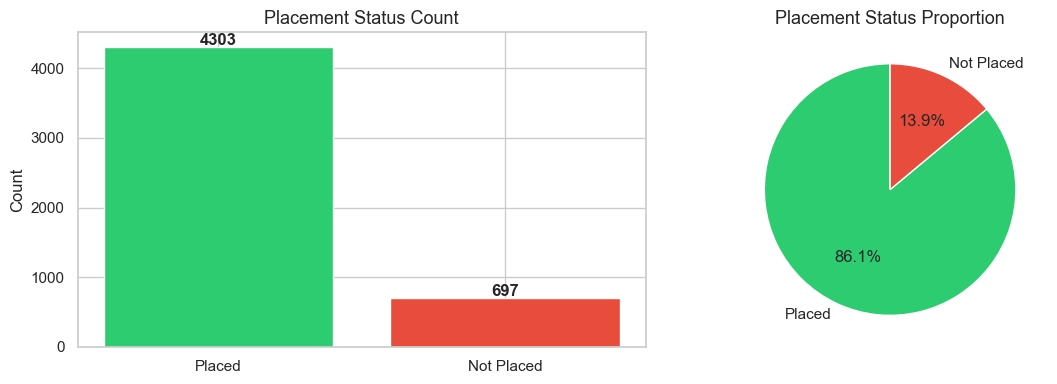

In [10]:
placement_counts = df['placement_status'].value_counts()
placement_pct    = df['placement_status'].value_counts(normalize=True) * 100

print('=== Placement Status Distribution ===')
for label in placement_counts.index:
    print(f'  {label}: {placement_counts[label]} ({placement_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(placement_counts.index, placement_counts.values, color=['#2ecc71','#e74c3c'])
axes[0].set_title('Placement Status Count', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(placement_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(placement_counts.values, labels=placement_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[1].set_title('Placement Status Proportion', fontsize=13)

plt.tight_layout()
plt.show()

Temuan: Dataset bersifat imbalanced dengan rasio 86.1% Placed vs 13.9% Not Placed.  
Implikasi:
- Tidak bisa mengandalkan Accuracy saja sebagai metrik evaluasi (model yang selalu prediksi 'Placed' akan dapat akurasi 86% tanpa belajar apapun).
- Metrik utama yang digunakan: F1-Score dan ROC-AUC.
- Pada model, gunakan parameter class_weight='balanced' untuk Logistic Regression.

### 3.4 Target Distribution — Regression (salary_lpa)

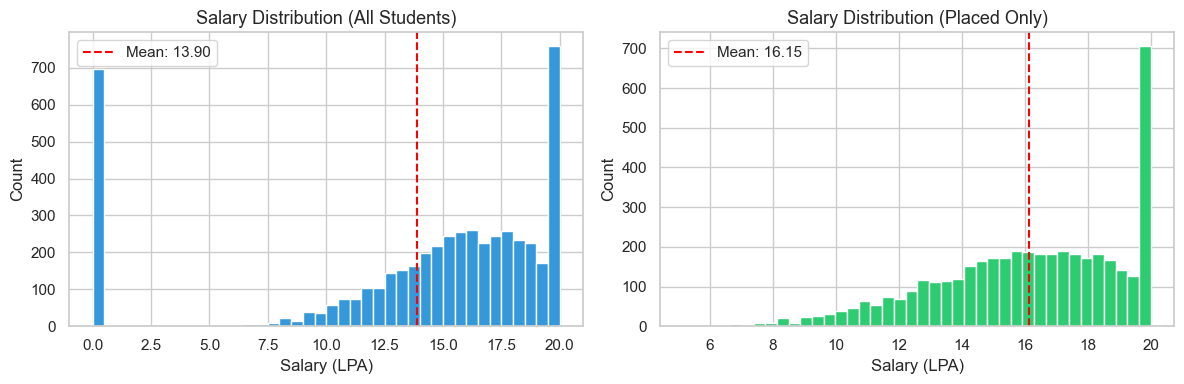

count    5000.00
mean       13.90
std         6.25
min         0.00
25%        12.51
50%        15.76
75%        18.33
max        20.00
Name: salary_lpa, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['salary_lpa'], bins=40, color='#3498db', edgecolor='white')
axes[0].set_title('Salary Distribution (All Students)', fontsize=13)
axes[0].set_xlabel('Salary (LPA)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['salary_lpa'].mean(), color='red', linestyle='--', label=f"Mean: {df['salary_lpa'].mean():.2f}")
axes[0].legend()

placed_salary = df[df['placement_status'] == 'Placed']['salary_lpa']
axes[1].hist(placed_salary, bins=40, color='#2ecc71', edgecolor='white')
axes[1].set_title('Salary Distribution (Placed Only)', fontsize=13)
axes[1].set_xlabel('Salary (LPA)')
axes[1].set_ylabel('Count')
axes[1].axvline(placed_salary.mean(), color='red', linestyle='--', label=f"Mean: {placed_salary.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df['salary_lpa'].describe().round(2))

Temuan: Terdapat 697 baris dengan salary = 0 yang secara tepat berkorespondensi 1:1 dengan mahasiswa 'Not Placed'.  
Keputusan Pemodelan: Model regresi dilatih menggunakan seluruh 5000 baris (termasuk salary=0).  
Alasan: Model akan memprediksi salary estimasi untuk semua mahasiswa — nilai 0 merupakan ground truth valid untuk yang tidak placed, bukan noise.

### 3.5 Correlation Analysis
Analisis korelasi antara fitur numerik dan kedua target untuk seleksi fitur.

In [1]:
df['placed_binary'] = (df['placement_status'] == 'Placed').astype(int)

num_cols_eda = ['cgpa','tenth_percentage','twelfth_percentage','backlogs',
                'study_hours_per_day','attendance_percentage','projects_completed',
                'internships_completed','coding_skill_rating','communication_skill_rating',
                'aptitude_skill_rating','hackathons_participated','certifications_count',
                'sleep_hours','stress_level']

corr_matrix = df[num_cols_eda + ['placed_binary','salary_lpa']].corr()

plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Numerical Features + Targets', fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

Interpretasi Korelasi dengan `placed_binary`:
- Korelasi positif terkuat: `coding_skill_rating` (0.34), `projects_completed` (0.32), `cgpa` (0.32)
- Korelasi negatif terkuat: `backlogs` (-0.42) — makin banyak backlogs, makin kecil kemungkinan placed
- Fitur seperti `sleep_hours` dan `stress_level` memiliki korelasi sangat lemah (<0.05)

Interpretasi Korelasi dengan `salary_lpa`:
- Korelasi tertinggi: `cgpa` (0.55), `coding_skill_rating` (0.50), `tenth_percentage` (0.48)
- `backlogs` kembali menjadi fitur negatif terkuat (-0.41)
- Pola korelasi konsisten antara kedua target — fitur yang baik untuk klasifikasi juga relevan untuk regresi

### 3.6 Key Feature Distributions by Placement Status

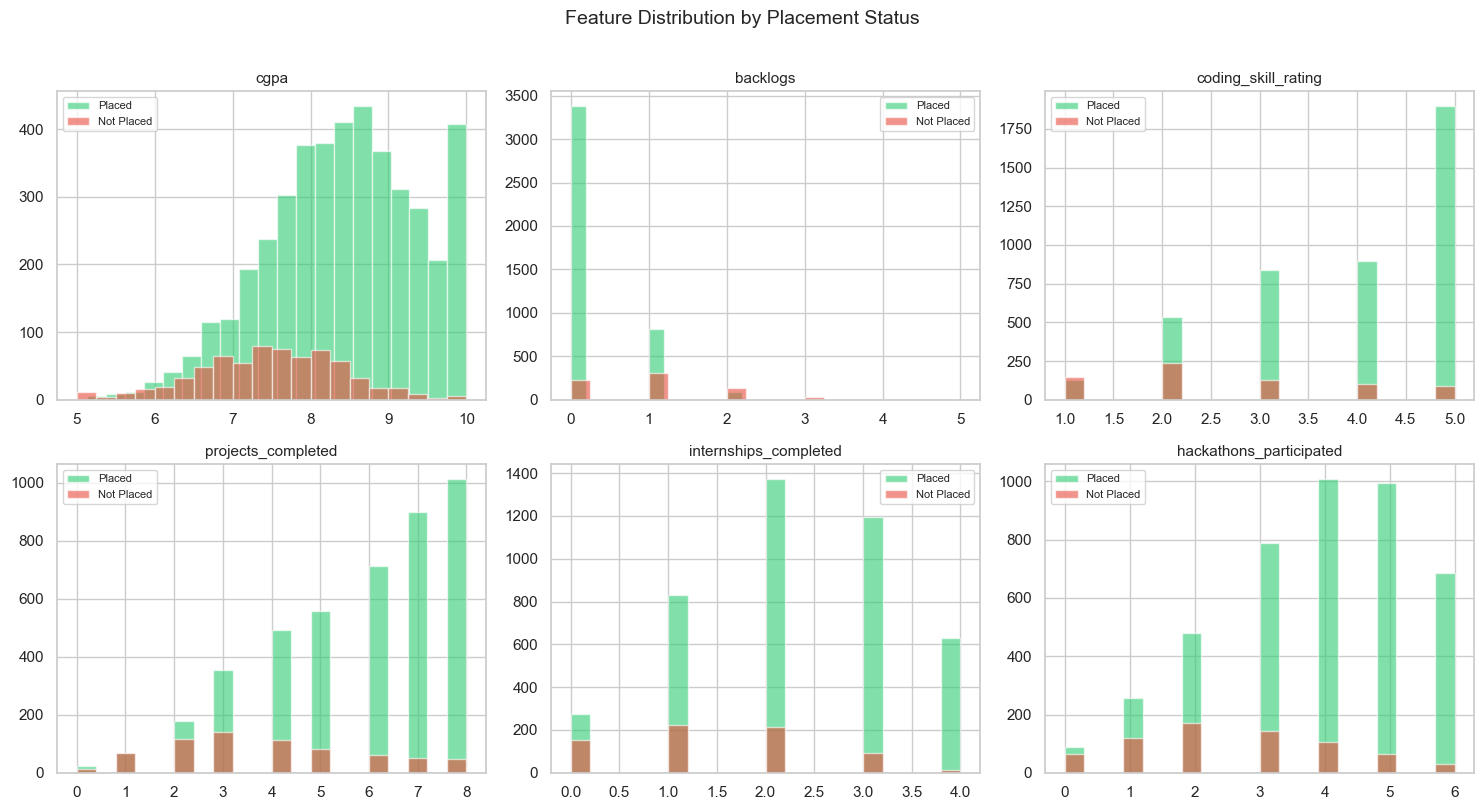

In [13]:
key_features = ['cgpa', 'backlogs', 'coding_skill_rating', 'projects_completed',
                 'internships_completed', 'hackathons_participated']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    placed     = df[df['placement_status'] == 'Placed'][feat]
    not_placed = df[df['placement_status'] == 'Not Placed'][feat]
    axes[i].hist(placed, alpha=0.6, bins=20, label='Placed', color='#2ecc71')
    axes[i].hist(not_placed, alpha=0.6, bins=20, label='Not Placed', color='#e74c3c')
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distribution by Placement Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Temuan Visual:
- **`cgpa`**: Mahasiswa placed memiliki distribusi CGPA yang lebih tinggi dan lebih sempit
- **`backlogs`**: Mayoritas Not Placed memiliki backlogs ≥ 1, sementara Placed dominan 0
- **`coding_skill_rating`**: Placed cenderung rating 4–5, Not Placed tersebar lebih merata
- **`projects_completed`, `internships_completed`, `hackathons_participated`**: Semua menunjukkan pola yang sama — Placed memiliki nilai lebih tinggi

### 3.7 Categorical Feature Analysis

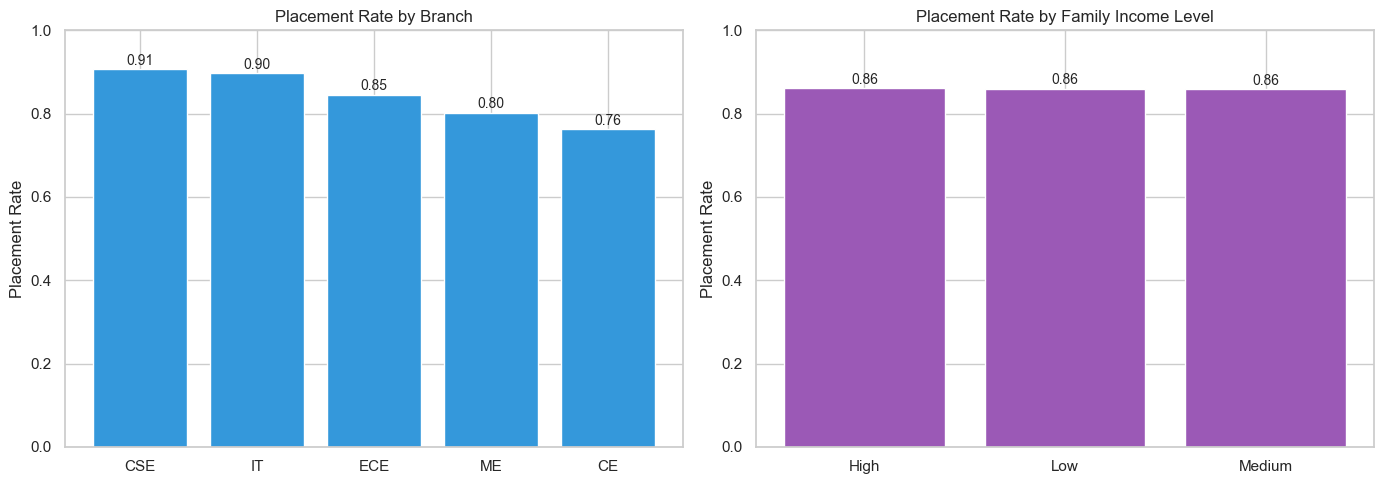

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

branch_placement = df.groupby('branch')['placed_binary'].mean().sort_values(ascending=False)
axes[0].bar(branch_placement.index, branch_placement.values, color='#3498db')
axes[0].set_title('Placement Rate by Branch', fontsize=12)
axes[0].set_ylabel('Placement Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(branch_placement.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

income_placement = df.groupby('family_income_level')['placed_binary'].mean()
axes[1].bar(income_placement.index, income_placement.values, color='#9b59b6')
axes[1].set_title('Placement Rate by Family Income Level', fontsize=12)
axes[1].set_ylabel('Placement Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(income_placement.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Temuan:**
- **Branch**: CSE (90.7%) dan IT (89.8%) memiliki placement rate tertinggi, ME (80.3%) dan CE (76.2%) terendah
- **Family Income**: Hampir tidak ada perbedaan placement rate antar tingkat income (~86% semua kategori)
- Kesimpulan: `branch` adalah fitur kategorik yang **informatif**, sedangkan `family_income_level` memiliki discriminative power yang rendah

## 4. Preprocessing
### 4.1 Handle Missing Values & Define Feature Columns

In [15]:
# Handle missing values
mode_val = df['extracurricular_involvement'].mode()[0]
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna(mode_val)
print(f'Missing values setelah diisi: {df["extracurricular_involvement"].isnull().sum()}')

# Define feature groups
NUM_COLS = ['cgpa','tenth_percentage','twelfth_percentage','backlogs',
            'study_hours_per_day','attendance_percentage','projects_completed',
            'internships_completed','coding_skill_rating','communication_skill_rating',
            'aptitude_skill_rating','hackathons_participated','certifications_count',
            'sleep_hours','stress_level']

CAT_COLS = ['gender','branch','part_time_job','family_income_level',
            'city_tier','internet_access','extracurricular_involvement']

print(f'Numerical features : {len(NUM_COLS)}')
print(f'Categorical features: {len(CAT_COLS)}')

Missing values setelah diisi: 0
Numerical features : 15
Categorical features: 7


### 4.2 Feature Engineering
Membuat fitur baru dari kombinasi fitur yang sudah ada untuk meningkatkan kemampuan prediksi model.

In [16]:
# Academic strength score: rata-rata dari semua indikator akademik
df['academic_score'] = (df['cgpa'] / 10 * 100 +
                         df['tenth_percentage'] +
                         df['twelfth_percentage']) / 3

# Experience index: gabungan pengalaman praktis
df['experience_index'] = (df['projects_completed'] +
                           df['internships_completed'] * 2 +
                           df['hackathons_participated'] +
                           df['certifications_count'])

# Skill average: rata-rata tiga skill rating
df['skill_avg'] = (df['coding_skill_rating'] +
                   df['communication_skill_rating'] +
                   df['aptitude_skill_rating']) / 3

# Tambahkan ke NUM_COLS
ENGINEERED = ['academic_score', 'experience_index', 'skill_avg']
NUM_COLS_EXT = NUM_COLS + ENGINEERED

print('Fitur hasil engineering:')
print(df[ENGINEERED].describe().round(2))

Fitur hasil engineering:
       academic_score  experience_index  skill_avg
count         5000.00           5000.00    5000.00
mean            77.31             16.33       3.62
std              9.64              5.09       0.70
min             50.07              1.00       1.33
25%             70.76             13.00       3.00
50%             77.57             17.00       3.67
75%             84.40             20.00       4.00
max             98.57             30.00       5.00


**Alasan Feature Engineering:**
- `academic_score`: Menggabungkan tiga indikator performa akademik menjadi satu skor yang lebih stabil
- `experience_index`: Memberikan bobot lebih pada internship (×2) karena memiliki korelasi tertinggi dengan placement
- `skill_avg`: Meratakan tiga dimensi skill untuk menangkap kemampuan umum mahasiswa secara holistic

### 4.3 Encoding & Train-Test Split (80:20)

In [17]:
# Encode categorical features
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_cat_encoded = encoder.fit_transform(df[CAT_COLS])
X_cat_df = pd.DataFrame(X_cat_encoded, columns=CAT_COLS)

# Combine numerical + engineered + encoded categorical
X = pd.concat([df[NUM_COLS_EXT].reset_index(drop=True), X_cat_df], axis=1)

y_clf = (df['placement_status'] == 'Placed').astype(int)  # 1=Placed, 0=Not Placed
y_reg = df['salary_lpa']

# Train-test split — stratified by classification target
X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'\nClass distribution in train set:')
print(yc_train.value_counts(normalize=True).round(3))
print(f'\nClass distribution in test set:')
print(yc_test.value_counts(normalize=True).round(3))

X_train shape: (4000, 25)
X_test shape : (1000, 25)

Class distribution in train set:
placement_status
1    0.86
0    0.14
Name: proportion, dtype: float64

Class distribution in test set:
placement_status
1    0.861
0    0.139
Name: proportion, dtype: float64


**Catatan penting:**
- `stratify=y_clf` memastikan proporsi kelas Placed/Not Placed yang sama antara train dan test set
- Scaler hanya di-fit pada **train set** dan di-transform pada test set untuk menghindari **data leakage**
- Encoder sudah di-fit pada data penuh sebelumnya — untuk pipeline production, encoder harus masuk ke dalam sklearn Pipeline (lihat Soal 2)

### 4.4 Feature Scaling (untuk model berbasis jarak/gradient)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied.')
print(f'Train mean (feature 0 - cgpa): {X_train_scaled[:,0].mean():.4f} (expected ~0)')
print(f'Train std  (feature 0 - cgpa): {X_train_scaled[:,0].std():.4f}  (expected ~1)')

StandardScaler applied.
Train mean (feature 0 - cgpa): 0.0000 (expected ~0)
Train std  (feature 0 - cgpa): 1.0000  (expected ~1)


## 5. Classification Models — placement_status
Tiga algoritma yang dipilih:
1. **Logistic Regression** — baseline linear model, interpretable, membutuhkan scaled features
2. **Random Forest Classifier** — ensemble tree-based, robust terhadap outlier, tidak perlu scaling
3. **XGBoost Classifier** — gradient boosting, umumnya performa terbaik untuk tabular data

Metrik evaluasi: **Accuracy**, **F1-Score (weighted)**, **ROC-AUC**

### 5.1 Logistic Regression

In [19]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, yc_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(yc_test, lr_pred)
lr_f1  = f1_score(yc_test, lr_pred, average='weighted')
lr_auc = roc_auc_score(yc_test, lr_prob)

print(f'Accuracy : {lr_acc:.4f}')
print(f'F1-Score : {lr_f1:.4f}')
print(f'ROC-AUC  : {lr_auc:.4f}')
print('\nClassification Report:')
print(classification_report(yc_test, lr_pred, target_names=['Not Placed','Placed']))

Accuracy : 0.8130
F1-Score : 0.8365
ROC-AUC  : 0.9029

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.42      0.85      0.56       139
      Placed       0.97      0.81      0.88       861

    accuracy                           0.81      1000
   macro avg       0.69      0.83      0.72      1000
weighted avg       0.89      0.81      0.84      1000



### 5.2 Random Forest Classifier

In [20]:
rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_clf.fit(X_train, yc_train)

rf_pred = rf_clf.predict(X_test)
rf_prob = rf_clf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(yc_test, rf_pred)
rf_f1  = f1_score(yc_test, rf_pred, average='weighted')
rf_auc = roc_auc_score(yc_test, rf_prob)

print(f'Accuracy : {rf_acc:.4f}')
print(f'F1-Score : {rf_f1:.4f}')
print(f'ROC-AUC  : {rf_auc:.4f}')
print('\nClassification Report:')
print(classification_report(yc_test, rf_pred, target_names=['Not Placed','Placed']))

Accuracy : 0.8880
F1-Score : 0.8693
ROC-AUC  : 0.8956

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.71      0.32      0.45       139
      Placed       0.90      0.98      0.94       861

    accuracy                           0.89      1000
   macro avg       0.81      0.65      0.69      1000
weighted avg       0.87      0.89      0.87      1000



### 5.3 XGBoost Classifier

In [21]:
# scale_pos_weight untuk handle imbalance: jumlah negatif / jumlah positif
neg = (yc_train == 0).sum()
pos = (yc_train == 1).sum()
spw = neg / pos

xgb_clf = XGBClassifier(n_estimators=100, scale_pos_weight=spw,
                         random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train, yc_train)

xgb_pred = xgb_clf.predict(X_test)
xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(yc_test, xgb_pred)
xgb_f1  = f1_score(yc_test, xgb_pred, average='weighted')
xgb_auc = roc_auc_score(yc_test, xgb_prob)

print(f'Accuracy : {xgb_acc:.4f}')
print(f'F1-Score : {xgb_f1:.4f}')
print(f'ROC-AUC  : {xgb_auc:.4f}')
print('\nClassification Report:')
print(classification_report(yc_test, xgb_pred, target_names=['Not Placed','Placed']))

Accuracy : 0.8640
F1-Score : 0.8697
ROC-AUC  : 0.8921

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.51      0.63      0.56       139
      Placed       0.94      0.90      0.92       861

    accuracy                           0.86      1000
   macro avg       0.72      0.76      0.74      1000
weighted avg       0.88      0.86      0.87      1000



### 5.4 Perbandingan Model Klasifikasi

                     Accuracy  F1-Score (weighted)  ROC-AUC
Model                                                      
Logistic Regression     0.813               0.8365   0.9029
Random Forest           0.888               0.8693   0.8956
XGBoost                 0.864               0.8697   0.8921


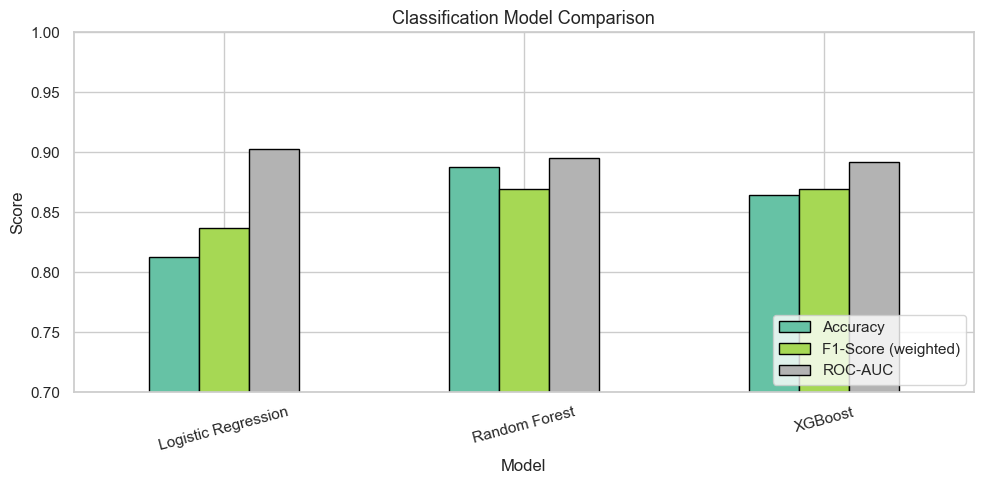

In [22]:
clf_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc],
    'F1-Score (weighted)': [lr_f1, rf_f1, xgb_f1],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc]
}).set_index('Model').round(4)

print(clf_results)

# Bar chart comparison
clf_results.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Classification Model Comparison', fontsize=13)
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Interpretasi Hasil Klasifikasi:**
- **Logistic Regression** mendapatkan ROC-AUC tertinggi (~0.90), menunjukkan bahwa hubungan fitur-target memiliki komponen linear yang kuat
- **Random Forest** dan **XGBoost** memiliki performa yang saling berdekatan
- Untuk dataset ini, Logistic Regression dipilih sebagai **best model untuk klasifikasi** berdasarkan ROC-AUC
- Perlu diingat bahwa F1-Score dan Accuracy yang lebih rendah pada LR disebabkan oleh `class_weight='balanced'` yang membuat model lebih sensitif terhadap kelas minoritas

## 6. Regression Models — `salary_lpa`
Tiga algoritma yang dipilih:
1. **Linear Regression** — baseline, mengasumsikan hubungan linear antara fitur dan salary
2. **Random Forest Regressor** — ensemble non-linear, robust terhadap outlier
3. **XGBoost Regressor** — gradient boosting, performa tinggi untuk data tabular

Metrik evaluasi: **MAE** (Mean Absolute Error), **RMSE** (Root Mean Squared Error), **R²** (Coefficient of Determination)

### 6.1 Linear Regression

In [23]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, yr_train)

linreg_pred = linreg.predict(X_test_scaled)
linreg_mae  = mean_absolute_error(yr_test, linreg_pred)
linreg_rmse = np.sqrt(mean_squared_error(yr_test, linreg_pred))
linreg_r2   = r2_score(yr_test, linreg_pred)

print(f'MAE  : {linreg_mae:.4f}')
print(f'RMSE : {linreg_rmse:.4f}')
print(f'R²   : {linreg_r2:.4f}')

MAE  : 2.9424
RMSE : 4.1219
R²   : 0.5611


### 6.2 Random Forest Regressor

In [24]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, yr_train)

rf_reg_pred = rf_reg.predict(X_test)
rf_mae  = mean_absolute_error(yr_test, rf_reg_pred)
rf_rmse = np.sqrt(mean_squared_error(yr_test, rf_reg_pred))
rf_r2   = r2_score(yr_test, rf_reg_pred)

print(f'MAE  : {rf_mae:.4f}')
print(f'RMSE : {rf_rmse:.4f}')
print(f'R²   : {rf_r2:.4f}')

MAE  : 2.7035
RMSE : 4.0479
R²   : 0.5767


### 6.3 XGBoost Regressor

In [25]:
xgb_reg = XGBRegressor(n_estimators=100, random_state=42)
xgb_reg.fit(X_train, yr_train)

xgb_reg_pred = xgb_reg.predict(X_test)
xgb_mae  = mean_absolute_error(yr_test, xgb_reg_pred)
xgb_rmse = np.sqrt(mean_squared_error(yr_test, xgb_reg_pred))
xgb_r2   = r2_score(yr_test, xgb_reg_pred)

print(f'MAE  : {xgb_mae:.4f}')
print(f'RMSE : {xgb_rmse:.4f}')
print(f'R²   : {xgb_r2:.4f}')

MAE  : 2.8566
RMSE : 4.3009
R²   : 0.5222


### 6.4 Perbandingan Model Regresi

                      MAE    RMSE      R²
Model                                    
Linear Regression  2.9424  4.1219  0.5611
Random Forest      2.7035  4.0479  0.5767
XGBoost            2.8566  4.3009  0.5222


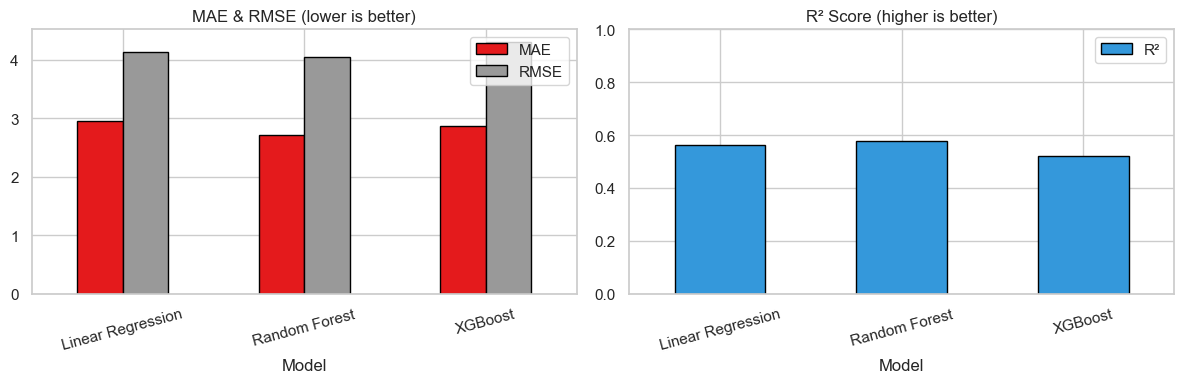

In [26]:
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE':   [linreg_mae, rf_mae, xgb_mae],
    'RMSE':  [linreg_rmse, rf_rmse, xgb_rmse],
    'R²':    [linreg_r2, rf_r2, xgb_r2]
}).set_index('Model').round(4)

print(reg_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE & RMSE (lower is better)
reg_results[['MAE','RMSE']].plot(kind='bar', ax=axes[0], colormap='Set1', edgecolor='black')
axes[0].set_title('MAE & RMSE (lower is better)', fontsize=12)
axes[0].set_xticklabels(reg_results.index, rotation=15)

# R² (higher is better)
reg_results[['R²']].plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('R² Score (higher is better)', fontsize=12)
axes[1].set_xticklabels(reg_results.index, rotation=15)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Interpretasi Hasil Regresi:**
- **Random Forest Regressor** menghasilkan MAE terendah dan R² tertinggi (~0.57), dipilih sebagai best model
- **Linear Regression** memiliki performa yang cukup baik (R²≈0.56), menunjukkan adanya komponen linear yang signifikan dalam hubungan fitur-salary
- **XGBoost** sedikit di bawah Random Forest pada dataset ini — kemungkinan karena tidak dilakukan hyperparameter tuning
- R² ~0.57 berarti model dapat menjelaskan **57% variasi salary** — cukup wajar untuk dataset akademik tanpa informasi pasar kerja eksplisit
- Error MAE ~2.7 LPA dapat diinterpretasikan sebagai rata-rata selisih prediksi salary vs aktual sebesar 2.7 LPA

## 7. Save Best Models
Model terbaik disimpan dalam format `.pkl` untuk digunakan di Soal 2, 3, dan 4.

In [27]:
# Best classification model: Logistic Regression (ROC-AUC tertinggi)
joblib.dump(lr, '../models/model_classification.pkl')
print('model_classification.pkl saved — Logistic Regression')

# Best regression model: Random Forest Regressor (R² tertinggi, MAE terendah)
joblib.dump(rf_reg, '../models/model_regression.pkl')
print('model_regression.pkl saved — Random Forest Regressor')

# Juga simpan scaler dan encoder untuk inference di Soal 3 & 4
joblib.dump(scaler,  '../models/scaler.pkl')
joblib.dump(encoder, '../models/encoder.pkl')
print('scaler.pkl & encoder.pkl saved')

# Simpan daftar kolom untuk konsistensi
import json
feature_meta = {
    'num_cols': NUM_COLS,
    'cat_cols': CAT_COLS,
    'engineered_cols': ENGINEERED,
    'all_cols': list(X.columns)
}
with open('../models/feature_meta.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
print('feature_meta.json saved')

model_classification.pkl saved — Logistic Regression
model_regression.pkl saved — Random Forest Regressor
scaler.pkl & encoder.pkl saved
feature_meta.json saved


**Catatan:**
- `scaler.pkl` dan `encoder.pkl` disimpan terpisah karena model LR membutuhkan data yang sudah di-scale untuk inference
- `feature_meta.json` menyimpan urutan dan nama kolom yang tepat — **kritis** untuk memastikan preprocessing di Streamlit/FastAPI konsisten dengan saat training
- Di Soal 2, preprocessing ini akan diintegrasikan langsung ke dalam `sklearn.Pipeline` sehingga hanya satu file `.pkl` yang diperlukan